# Notebook 03: Preprocessing

**Objective:**
Apply bandpass filtering, detrending, and normalization to the full 10-second signals. Save the clean signals to `preprocessed_signals.npz`.

In [4]:
import sys
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

project_root = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import BUTPPGDataLoader
from src.preprocessing import preprocess_ppg
from src.visualization import plot_signal

DATA_DIR = os.path.join(project_root, 'brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0')
PROCESSED_DIR = os.path.join(project_root, 'processed_data')

In [5]:
loader = BUTPPGDataLoader(DATA_DIR)
df_labels = pd.read_csv(os.path.join(PROCESSED_DIR, 'labels_3class.csv'))

preprocessed_dict = {}

for index, row in tqdm(df_labels.iterrows(), total=len(df_labels), desc="Preprocessing"):
    rec_id = str(row['ID'])
    raw, _, fs, _ = loader.load_signals(rec_id)
    if raw is not None:
        clean = preprocess_ppg(raw, fs)
        if clean is not None:
            preprocessed_dict[rec_id] = clean

out_file = os.path.join(PROCESSED_DIR, 'preprocessed_signals.npz')
np.savez_compressed(out_file, **preprocessed_dict)
print(f"Saved {len(preprocessed_dict)} signals to {out_file}")

Preprocessing:   0%|          | 0/3888 [00:00<?, ?it/s]

Preprocessing: 100%|██████████| 3888/3888 [01:16<00:00, 50.84it/s]


Saved 3888 signals to c:\Users\rajka\PPG-IIIT\processed_data\preprocessed_signals.npz


### Validation Check

Total signals saved: 3888
Sample signal '100001' length: 300
Sample signal data type: float64


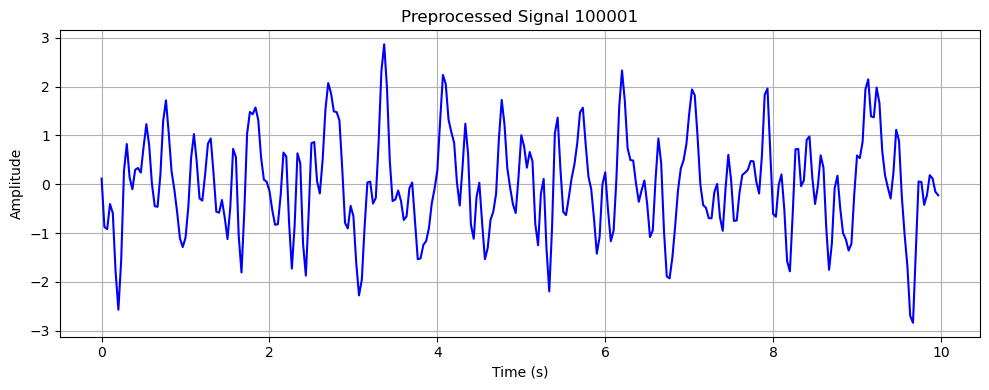

In [6]:
signals_loaded = np.load(out_file)
keys = list(signals_loaded.keys())

print("Total signals saved:", len(keys))
if len(keys) > 0:
    sample_key = keys[0]
    sample_sig = signals_loaded[sample_key]
    print(f"Sample signal '{sample_key}' length: {len(sample_sig)}")
    print(f"Sample signal data type: {sample_sig.dtype}")
    plot_signal(sample_sig, title=f"Preprocessed Signal {sample_key}")